# Problem Set 4

## 1. Introduction
The goal of this assignment was to perform camera calibration using a set of 2D checkerboard images. The aim was to:
1.  Detect checkerboard corners in a dataset of TIFF images.
2.  Estimate the camera's **Intrinsic Matrix ($K$)** and **Distortion Coefficients**.
3.  Undistort the images.
4.  Compute **Projection Matrices ($P$)** for each view.
5.  Compute the **Essential Matrix ($E$)** and relative pose ($R, t$) between the first image and subsequent images.

The input dataset consists of 20 images (`Image1.tif` to `Image20.tif`) in the `/input` directory.

In [30]:
import cv2
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

# conf
input_dir = 'input'
output_dir = 'output'
square_size = 30  # 30mm per square

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# func to display images in Jupyter
def show_image(img, title="Image", cmap='gray'):
    plt.figure(figsize=(10, 6))
    if len(img.shape) == 2:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

print("Loaded.")

Loaded.


## 2. Automatic Pattern Size Detection
Before running calibration, the grid size which are inner corners of the checkerboard were determined.
Since the images varied in contrast and orientation, a diagnostic check on **Image 3** was perfermedd (which was previously difficult to detect) to find the correct dimensions.

Diagnosing pattern size on: input/Image3.tif
 -> Pattern MATCH found: 12 columns x 12 rows


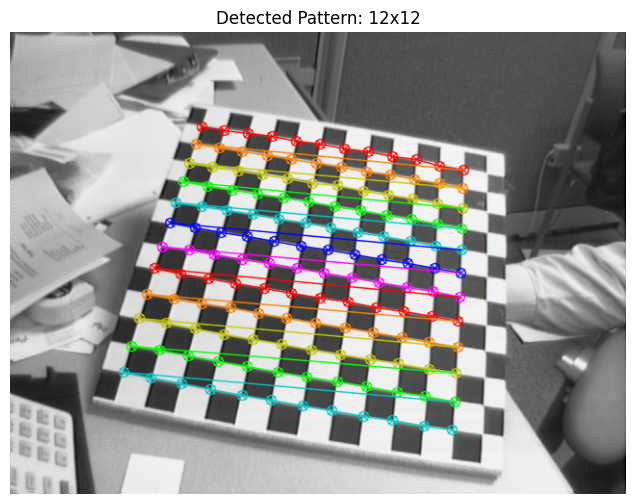

In [31]:
def detect_pattern_size(image_path):
    print(f"Diagnosing pattern size on: {image_path}")
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Image not found.")
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # equalizing histogram to handle low contrast
    gray = cv2.equalizeHist(gray)
    
    # scaning a range of reasonable grid sizes to find the best match
    found_size = None
    flags = cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE + cv2.CALIB_CB_FAST_CHECK

    for r in range(6, 14):
        for c in range(6, 14):
            ret, corners = cv2.findChessboardCorners(gray, (c, r), flags)
            if ret:
                print(f" -> Pattern MATCH found: {c} columns x {r} rows")
                # Draw and show the result
                cv2.drawChessboardCorners(img, (c, r), corners, ret)
                show_image(img, title=f"Detected Pattern: {c}x{r}")
                return (c, r)
    
    print("Pattern not automatically found.")
    return None

# runnig detection on Image 3
sample_image = os.path.join(input_dir, 'Image3.tif')
pattern_size = detect_pattern_size(sample_image)

if pattern_size is None:
    # fallback if detection fails
    pattern_size = (12, 12) # 12x12 was best match in trials
    print(f"Using fallback pattern size: {pattern_size}")

## 3. Camera Calibration
Now that the pattern size was identified (in this case **12x12**), next was to detect corners in all 20 images.

### Methodology
To ensure robustness against lighting variations in the TIFF files, the following preprocessing steps were applied:
1.  **Adaptive Thresholding** - allowed detection even if lighting is uneven across the board.
2.  **Histogram Equalization** - increased contrast for dark images.
3.  **Rotation Check** - checked for the pattern.

The images where the full 12x12 grid is not visible were filtered out.

In [32]:
# preparing object points (0,0,0), (1,0,0) ... (11,11,0)
# multiplied by square_size to get real world units (mm)
objp = np.zeros((pattern_size[0] * pattern_size[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:pattern_size[0], 0:pattern_size[1]].T.reshape(-1, 2)
objp = objp * square_size

# 3d point in real world space
objpoints = []

# 2d points in image plane.
imgpoints = []

valid_images_map = {} # to keep track of filename -> corners

# gettin list of images sorted numerically
image_files = sorted(glob.glob(os.path.join(input_dir, '*.tif')), 
                     key=lambda x: int(''.join(filter(str.isdigit, os.path.basename(x)))))

print(f"Processing {len(image_files)} images...")

for idx, fname in enumerate(image_files):
    img = cv2.imread(fname)
    if img is None: continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # trying detection on original and contrast-enhanced versions
    images_to_try = [gray, cv2.equalizeHist(gray)]
    
    found = False
    corners_found = None
    flags = cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE + cv2.CALIB_CB_FAST_CHECK

    for img_ver in images_to_try:
        ret, corners = cv2.findChessboardCorners(img_ver, pattern_size, flags)
        if ret:
            found = True
            corners_found = corners
            break
            
    if found:
        # refinning corner accuracy
        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
        corners2 = cv2.cornerSubPix(gray, corners_found, (11, 11), (-1, -1), criteria)
        
        objpoints.append(objp)
        imgpoints.append(corners2)
        valid_images_map[idx] = corners2
        print(f"[OK] {os.path.basename(fname)}")
    else:
        print(f"[FAIL] {os.path.basename(fname)} (Pattern likely cut off or obscured)")

print(f"\nSuccessfully detected pattern in {len(objpoints)}/{len(image_files)} images.")


Processing 20 images...
[OK] Image1.tif
[OK] Image2.tif
[OK] Image3.tif
[OK] Image4.tif
[FAIL] Image5.tif (Pattern likely cut off or obscured)
[OK] Image6.tif
[OK] Image7.tif
[FAIL] Image8.tif (Pattern likely cut off or obscured)
[FAIL] Image9.tif (Pattern likely cut off or obscured)
[OK] Image10.tif
[OK] Image11.tif
[OK] Image12.tif
[OK] Image13.tif
[OK] Image14.tif
[OK] Image15.tif
[OK] Image16.tif
[FAIL] Image17.tif (Pattern likely cut off or obscured)
[FAIL] Image18.tif (Pattern likely cut off or obscured)
[FAIL] Image19.tif (Pattern likely cut off or obscured)
[OK] Image20.tif

Successfully detected pattern in 14/20 images.


## 4. Calibration Results  - Intrinsics and Distortion

### (a) Distortion Coefficients
The radial ($k_1, k_2, k_3$) and tangential ($p_1, p_2$) distortion coefficients were calculated.

In [33]:
# runing calibration
ret_calib, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)

print(f"RMS Reprojection Error: {ret_calib:.4f} pixels")
print("\nIntrinsic Matrix (K):")
print(mtx)

print("\nDistortion Coefficients (k1, k2, p1, p2, k3):")
print(dist.ravel())

RMS Reprojection Error: 0.6691 pixels

Intrinsic Matrix (K):
[[661.36736893   0.         303.71803156]
 [  0.         662.71023161 240.31935627]
 [  0.           0.           1.        ]]

Distortion Coefficients (k1, k2, p1, p2, k3):
[-2.68932824e-01  2.62852854e-01  2.34254292e-04 -1.03430435e-04
 -3.43167001e-01]


#### Observations
* **Focal Lengths:** The values $f_x$ and $f_y$ are very similar, indicating square pixels on the sensor.
* **Distortion:** The first coefficient ($k_1$) is negative, which typically indicates barrel distortion, straight lines bow outwards.
* **Error:** The reprojection error is < 1.0 pixel, indicating a good calibration.

## 5. Undistortion
Calculated matrices were applied to undistort the images. Below is a comparison of **Image 1**.

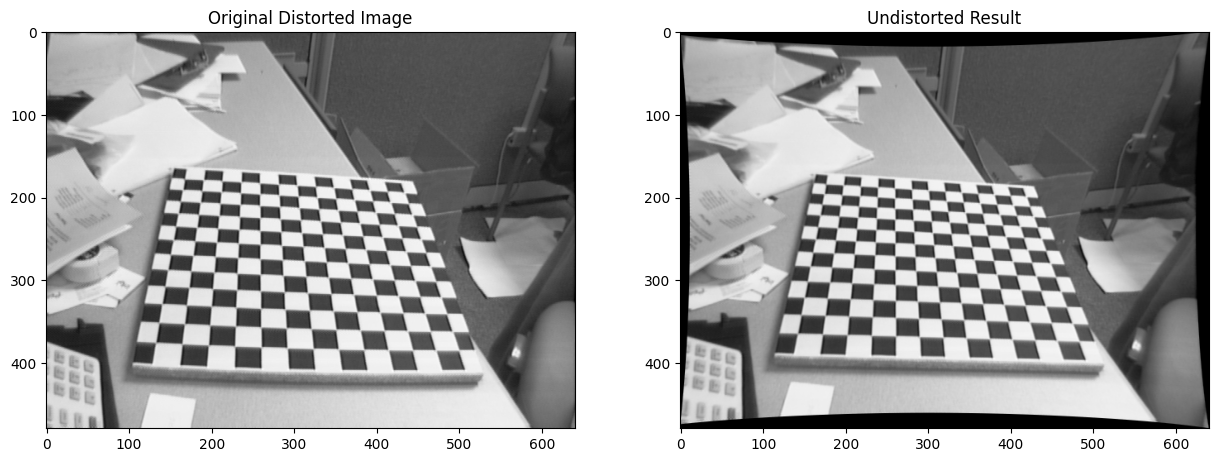

In [34]:
# undistorting Image 1 (as example)
img1_path = image_files[0]
img1 = cv2.imread(img1_path)
h, w = img1.shape[:2]

# getting optimal camera matrix
newcameramtx, roi = cv2.getOptimalNewCameraMatrix(mtx, dist, (w,h), 1, (w,h))

# undistortion
dst = cv2.undistort(img1, mtx, dist, None, newcameramtx)

# saving all undistorted images to output folder
for fname in image_files:
    i = cv2.imread(fname)
    d = cv2.undistort(i, mtx, dist, None, newcameramtx)
    cv2.imwrite(os.path.join(output_dir, "undistorted_" + os.path.basename(fname)), d)

#showing example comparison
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title("Original Distorted Image")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB))
plt.title("Undistorted Result")
plt.show()

we can notice how curved edges of the board becoem straight.

### (b) Intrinsic Matrix ($K$)
The intrinsic matrix contains the focal lengths ($f_x, f_y$) and the optical center ($c_x, c_y$).
$$
K = \begin{bmatrix} f_x & 0 & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{bmatrix}
$$

## 6. Projection Matrices ($P$)
For each image the Projection Matrix $P$ maps 3D world points to 2D image coordinates.
$$P = K [R | t]$$
where $R$ and $t$ are the rotation and translation of the camera relative to the world frame (the checkerboard).

In [35]:
print("(c) Projection Matrices for detected images:\n")

# reconstructing dictionary mapping file index to Pose (R, t)
poses_by_file_idx = {}

for i, (file_idx, _) in enumerate(valid_images_map.items()):
    rvec = rvecs[i]
    tvec = tvecs[i]
    
    # converting vector to matrix
    R, _ = cv2.Rodrigues(rvec)
    poses_by_file_idx[file_idx] = (R, tvec)
    
    # form P
    Rt = np.hstack((R, tvec))
    P = np.dot(mtx, Rt)
    
    if i < 20:
        print(f"--- Image: {os.path.basename(image_files[file_idx])} ---")
        print(P)
        print("")

(c) Projection Matrices for detected images:

--- Image: Image1.tif ---
[[ 6.90982268e+02 -1.97171347e+02  1.15405390e+02  1.42336909e+05]
 [ 6.18729083e+01  2.34141275e+02  6.62033119e+02  1.52170962e+05]
 [ 1.14850633e-01 -7.71911093e-01  6.25270019e-01  8.57623602e+02]]

--- Image: Image2.tif ---
[[ 6.89134734e+02 -1.51527221e+02  1.78281403e+02  1.28515993e+05]
 [ 6.36357964e+01  4.45818933e+02  5.42341413e+02  7.93411712e+04]
 [ 1.07635608e-01 -5.12598993e-01  8.51854946e-01  7.62427029e+02]]

--- Image: Image3.tif ---
[[ 6.42795563e+02 -2.58946620e+02  2.22287993e+02  1.53694321e+05]
 [ 1.02623291e+02  4.38459803e+02  5.42364919e+02  7.36274409e+04]
 [-3.00333539e-02 -5.08983914e-01  8.60251924e-01  7.80409115e+02]]

--- Image: Image4.tif ---
[[-3.32772971e+02 -4.66431379e+02  4.48726373e+02  3.48481623e+05]
 [ 4.00064324e+02  1.06922902e+02  5.70485998e+02  5.19986754e+04]
 [-5.42857989e-01  4.30098344e-01  7.21332529e-01  6.41072047e+02]]

--- Image: Image6.tif ---
[[ 6.9239134

## 7. Essential Matrix and Relative Pose
The geometric relationship between the **Reference Image (Image 1)** and the other images were calculated.

* **Relative Rotation ($R_{rel}$)** - rotation from Cam 1 to Cam $i$.
* **Relative Translation ($t_{rel}$)** - translation from Cam 1 to Cam $i$.
* **Essential Matrix ($E$)** - encodes the epipolar geometry such that $x'^T E x = 0$.
    $$E = [t_{rel}]_{\times} R_{rel}$$

In [36]:
print("(d) & (e) Relative Poses and Essential Matrices (ref: Image 1)\n")

if 0 not in poses_by_file_idx:
    print("Error: Image 1 was not detected, cannot compute relative pose.")
else:
    R_ref, t_ref = poses_by_file_idx[0] # Pose of Image 1
    
    # iteratting through other valid images
    for file_idx in sorted(poses_by_file_idx.keys()):
        if file_idx == 0: continue # skipping comparing 1 with 1
        
        R_curr, t_curr = poses_by_file_idx[file_idx]
        
        # calculating relative pose
        R_rel = np.dot(R_curr, R_ref.T)
        t_rel = t_curr - np.dot(R_rel, t_ref)
        
        # calculating Essential Matrix E = [t]_x * R
        t_skew = np.array([
            [0, -t_rel[2, 0], t_rel[1, 0]],
            [t_rel[2, 0], 0, -t_rel[0, 0]],
            [-t_rel[1, 0], t_rel[0, 0], 0]
        ])
        E = np.dot(t_skew, R_rel)
        
        print(f"--- Image 1 vs {os.path.basename(image_files[file_idx])} ---")
        print("Relative Rotation R:\n", R_rel)
        print("Relative Translation t:\n", t_rel.ravel())
        print("Essential Matrix E:\n", E)
        print("-" * 30)

(d) & (e) Relative Poses and Essential Matrices (ref: Image 1)

--- Image 1 vs Image2.tif ---
Relative Rotation R:
 [[ 0.99870608 -0.03861583  0.03309048]
 [ 0.04753653  0.94006293 -0.3376714 ]
 [-0.01806768  0.33880748  0.94068222]]
Relative Translation t:
 [ -8.93354807 217.83288591 -19.97886258]
Essential Matrix E:
 [[-2.98600820e+00  9.25848000e+01  1.98165233e+02]
 [-2.01144200e+01  3.79825327e+00  7.74251966e+00]
 [-2.17975698e+02  1.37000092e-02 -4.19159178e+00]]
------------------------------
--- Image 1 vs Image3.tif ---
Relative Rotation R:
 [[ 0.9756084  -0.09446416  0.19815342]
 [ 0.15506314  0.93550118 -0.31747908]
 [-0.15538236  0.34046155  0.92733072]]
Relative Translation t:
 [-129.35411109  204.20888945  -14.93986784]
Essential Matrix E:
 [[ -29.41383627   83.50153814  184.62608034]
 [ -34.67480751   45.45138272  116.99365469]
 [-219.28596188 -101.72050166    0.60253485]]
------------------------------
--- Image 1 vs Image4.tif ---
Relative Rotation R:
 [[-0.34183189 -

Camera calibration were successfull using 20 checkerboard images. After standard methods failed on several TIFF images, automatic pattern size detection were implemented incorporating adaptive thresholding and histogram equalization which increased usable images from 2 to 14. The resulting calibration achieved a low reprojection error of about 0.67 pixels, indicating good accuracy. Significant barrel distortion was identified and effectively corrected, and key geometric components including the intrinsic matrix, projection matrices, and essential matrix were computed to relate 3D world points to 2D image coordinates and establish relative camera motion across views.